# Sensitivity Improvement Experiments

## Motivation

The baseline classifier showed limited ICH sensitivity despite high specificity and reasonable AUROC. The train-to-OOF sensitivity gap also suggested possible overfitting, while class imbalance may have contributed to the limited detection of ICH cases.

## Objective

This notebook applies three complementary interventions together, targeting overfitting and class imbalance at different stages of the training pipeline:

1. **Intensity-based data augmentation** to increase image variability and improve generalization.
2. **`WeightedRandomSampler`** to increase the sampling frequency of the minority ICH class.
3. **Class-weighted cross-entropy loss** to give greater importance to errors on the minority ICH class.

The combined strategy is compared against the baseline to assess whether it improves ICH sensitivity without unacceptably degrading specificity.

Because weighted sampling and class-weighted loss address class imbalance through different mechanisms, applying them simultaneously may result in overcorrection. Their individual contributions are not isolated in this experiment and would require separate ablation experiments.


# 3. Training Interventions

The baseline training pipeline already applies small rotations, translations, horizontal flipping, and Gaussian noise. This section therefore introduces three additional interventions targeting **overfitting and class imbalance**.

### 3.1 Intensity Augmentation

Additional stochastic intensity variation is introduced through mild brightness and contrast changes. These transformations are applied **symmetrically to both ICH and No-ICH images**, increasing training variability while preserving the original class distribution.

The augmentation is applied dynamically during training, so each access to an image can produce a different intensity transformation. Validation and test images remain unchanged.

### 3.2 Weighted Sampling

A `WeightedRandomSampler` is used to increase the sampling frequency of ICH-positive samples during training. This addresses class imbalance at the **data sampling stage**, without creating duplicate images in the dataset.

### 3.3 Class-Weighted Loss

A class-weighted cross-entropy loss is used to give greater importance to errors on the minority ICH class. This addresses class imbalance at the **optimization stage**.

### 3.4 Combined Training Strategy

The three interventions are applied **together** during training:

* Intensity-based data augmentation
* `WeightedRandomSampler`
* Class-weighted cross-entropy loss

This combined configuration is evaluated against the baseline model using the same patient-level test split.



In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

from src.data_loading import load_ct_image, load_diagnosis
from src.dataset import CTICHImageDataset
from src.models import create_resnet18
from src.preprocessing import (
    compute_class_weights,
    create_patient_labels,
    create_stratified_folds,
    get_eval_transforms,
    get_train_transforms,
)
from src.training import train_model


In [2]:
# Load the diagnosis data and reproduce the fixed patient-level
# development/test split used by the baseline experiment.

DATA_DIR = Path("data")

diagnosis_df = load_diagnosis(DATA_DIR)
diagnosis_df["ICH"] = 1 - diagnosis_df["No_Hemorrhage"]

patient_labels = create_patient_labels(diagnosis_df)

split_path = DATA_DIR / "static_patient_split.json"

with open(split_path, "r") as f:
    split = json.load(f)

development_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["development"])
]

test_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["test"])
]

print(f"Development patients: {len(development_patients)}")
print(f"Test patients: {len(test_patients)}")

Development patients: 65
Test patients: 17


In [3]:
# Define only the additional offline augmentations that are not already
# included in the standard training preprocessing.

intensity_augmentation = transforms.Compose(
    [
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
        ),
    ]
)

# 4. Visualizing the Augmentations
Before training, the selected augmentation is visually inspected to verify that it introduces plausible intensity variation while preserving the relevant anatomical and pathological information.

In [ ]:
ich_samples = diagnosis_df[
    diagnosis_df["PatientNumber"].isin(split["development"])
    & (diagnosis_df["ICH"] == 1)
].sample(
    n=4,
    random_state=42,
)

ich_samples[
    ["PatientNumber", "SliceNumber", "ICH"]
]

,PatientNumber,SliceNumber,ICH
1291,91,19,1
21,49,22,1
618,69,18,1
1169,87,23,1


In [ ]:
original_images = []
augmented_images = []

for _, sample in ich_samples.iterrows():
    image = load_ct_image(
        DATA_DIR,
        patient_id=int(sample["PatientNumber"]),
        slice_number=int(sample["SliceNumber"]),
        window="brain",
    )

    augmented_image = intensity_augmentation(image)

    original_images.append(image)
    augmented_images.append(augmented_image)

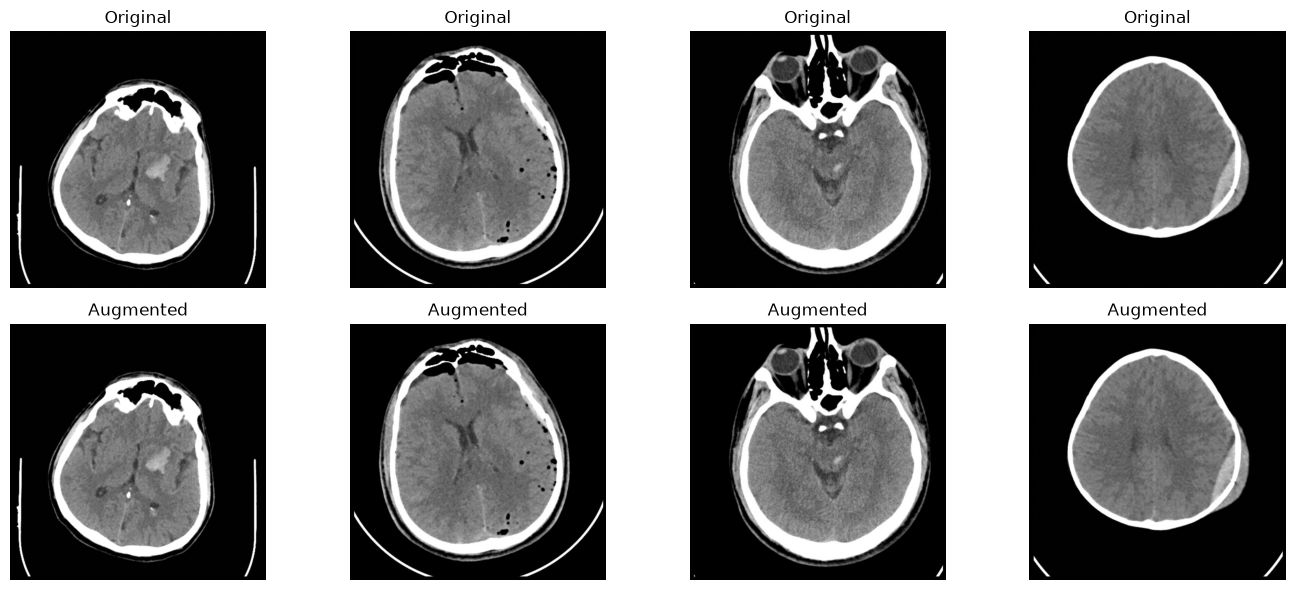

In [ ]:
# Display the selected ICH slices with the original images

fig, axes = plt.subplots(
    2,
    len(original_images),
    figsize=(14, 6),
)

for i, (original, augmented) in enumerate(
    zip(original_images, augmented_images)
):
    axes[0, i].imshow(original, cmap="gray")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(augmented, cmap="gray")
    axes[1, i].set_title("Augmented")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# 5. Experimental Setup

The experiment uses the same fixed patient-level development/test split as the baseline. The 65 development patients are used for cross-validation and final training, while the 17-patient test set remains completely untouched until final evaluation.

## 5.1 Training Dataset

The development training dataset contains one original sample per CT slice, with no offline duplication.

The standard training transformations from the baseline are retained. Additional stochastic brightness and contrast augmentation is applied during training to both ICH and No-ICH images.

In [ ]:
class AugmentedCTICHImageDataset(Dataset):
    """CT/ICH dataset with fresh stochastic intensity augmentation applied
    on every access, symmetric across both classes.
    """

    def __init__(
        self,
        diagnosis_df,
        data_dir,
        patient_ids,
        base_transform,
        augmentation=None,
    ):
        """
        Args:
            diagnosis_df: full diagnosis dataframe.
            data_dir: path to the data directory.
            patient_ids: patient IDs to include (e.g. development split).
            base_transform: the standard training transform pipeline
                (Resize, RandomHorizontalFlip, RandomRotation, RandomAffine,
                Grayscale, ToTensor, Normalize, AddGaussianNoise — i.e. your
                existing get_train_transforms()).
            augmentation: an additional stochastic intensity transform
                (e.g. transforms.ColorJitter(brightness=0.1, contrast=0.1))
                applied BEFORE base_transform, on every sample, regardless
                of class. Pass None to disable it entirely (equivalent to
                the plain baseline dataset).
        """
        self.data_dir = data_dir
        self.base_transform = base_transform
        self.augmentation = augmentation

        selected_samples = diagnosis_df[
            diagnosis_df["PatientNumber"].isin(patient_ids)
        ].reset_index(drop=True)

        # One entry per original slice — no duplication. Oversampling of
        # the ICH class is handled by the sampler at the DataLoader level,
        # not by inflating this list.
        self.samples = [
            {
                "patient_id": int(row["PatientNumber"]),
                "slice_number": int(row["SliceNumber"]),
                "label": int(row["ICH"]),
            }
            for _, row in selected_samples.iterrows()
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]

        image = load_ct_image(
            self.data_dir,
            patient_id=sample["patient_id"],
            slice_number=sample["slice_number"],
            window="brain",
        )

        if self.augmentation is not None:
            image = self.augmentation(image)

        image = self.base_transform(image)

        return image, torch.tensor(sample["label"], dtype=torch.long)


In [9]:
# Create the augmented development training dataset and the unchanged
# test dataset using the same preprocessing as the baseline experiment.

development_patient_ids = development_patients["PatientNumber"].tolist()
test_patient_ids = test_patients["PatientNumber"].tolist()

train_dataset = AugmentedCTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=development_patient_ids,
    base_transform=get_train_transforms(),
    augmentation=intensity_augmentation,
)

test_dataset = CTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=test_patient_ids,
    transform=get_eval_transforms(),
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 1983
Test samples: 518


## 5.2 Class Balancing

Class imbalance is addressed using a WeightedRandomSampler, which increases the sampling frequency of ICH-positive samples during training without duplicating samples in the dataset.

A class-weighted cross-entropy loss is also used to give greater importance to errors on the minority ICH class.

In [10]:
# Oversample the ICH class during training by assigning each sample a probability
# inversely proportional to its class frequency in the augmented dataset.

labels = np.array([s["label"] for s in train_dataset.samples])
class_counts = np.bincount(labels)
sample_weights = np.array([1.0 / class_counts[l] for l in labels])
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_dataset),
    replacement=True,
)

In [11]:
# Count the original and augmented samples to verify that exactly one
# additional sample was created for each ICH-positive training slice.

original_train_samples = diagnosis_df[
    diagnosis_df["PatientNumber"].isin(development_patient_ids)
]

num_original_samples = len(original_train_samples)
num_ich_samples = (original_train_samples["ICH"] == 1).sum()

print(f"Original training samples: {num_original_samples}")
print(f"Original ICH samples: {num_ich_samples}")
print(f"Expected augmented samples: {num_original_samples + num_ich_samples}")
print(f"Actual augmented samples: {len(train_dataset)}")

Original training samples: 1983
Original ICH samples: 256
Expected augmented samples: 2239
Actual augmented samples: 1983


## 5.3 Cross-Validation

A 4-fold patient-level stratified cross-validation is performed on the 65 development patients.

For each fold:

Training patients are augmented and sampled using the WeightedRandomSampler.
Validation patients are evaluated without augmentation.
The best model is selected based on validation F1-score.
Out-of-fold (OOF) predictions are collected from the best validation epoch of each fold.

OOF metrics are then computed at a threshold of 0.5.

In [ ]:
# Training configuration
BATCH_SIZE = 32
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 5

LEARNING_RATE = 1e-4

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

NUM_WORKERS = 4


WEIGHT_DECAY = 1e-4

# Patient-level split
patient_labels = create_patient_labels(diagnosis_df)

split_path = Path("data/static_patient_split.json")

with open(split_path, "r") as f:
    split = json.load(f)

development_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["development"])
]

test_patients = patient_labels.loc[
    patient_labels["PatientNumber"].isin(split["test"])
]

cv_folds = create_stratified_folds(development_patients, n_splits=4)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"

print(f"Using device: {device}")


# Store results separately for each weight-decay value and fold
fold_results = {}

# Train a separate model on each fold
for fold in cv_folds:
    fold_number = fold["fold"]

    print(f"\n{'=' * 20} Fold {fold_number} {'=' * 20}")

    train_patient_ids = fold["train"]["PatientNumber"].tolist()
    validation_patient_ids = fold["validation"]["PatientNumber"].tolist()

    train_dataset = AugmentedCTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=train_patient_ids,
        base_transform=get_train_transforms(),
        augmentation=intensity_augmentation,
    )

    validation_dataset = AugmentedCTICHImageDataset(
        diagnosis_df=diagnosis_df,
        data_dir=DATA_DIR,
        patient_ids=validation_patient_ids,
        base_transform=get_eval_transforms(),
        augmentation=None,
    )

    # Class balance is handled here, via the sampler, on the
    # non-inflated sample list -- not by duplicating ICH-positive rows.
    train_labels_list = np.array(
        [s["label"] for s in train_dataset.samples]
    )
    class_sample_counts = np.bincount(train_labels_list)
    sample_weights = np.array(
        [1.0 / class_sample_counts[label] for label in train_labels_list]
    )
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(train_dataset),
        replacement=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = create_resnet18(num_classes=2).to(device)

    train_labels = fold["train"]["ICH"].values

    class_weights = compute_class_weights(train_labels).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=SCHEDULER_FACTOR,
        patience=SCHEDULER_PATIENCE,
    )

    (
        model,
        history,
        best_validation_predictions,
        epoch_states,
        best_epoch,
    ) = train_model(
        model=model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
        checkpoint_metric="f1",
    )

    fold_results[fold_number] = {
        "model": model,
        "history": history,
        "best_validation_predictions": best_validation_predictions,
        "epoch_states": epoch_states,
        "best_epoch": best_epoch,
        "train_patient_ids": train_patient_ids,
        "validation_patient_ids": validation_patient_ids,
    }

print("\nFull cross-validation training completed.")

Using device: cpu

==================== Fold 1 ====================
Epoch 01/10 | Train Loss: 0.3712 | Train F1: 0.8311 | Val Loss: 0.4283 | Val F1: 0.2062 | Val Sensitivity: 0.1562 | Val Specificity: 0.9483 | Val AUROC: 0.7099 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.2224 | Train F1: 0.9136 | Val Loss: 0.5343 | Val F1: 0.2222 | Val Sensitivity: 0.2031 | Val Specificity: 0.9101 | Val AUROC: 0.7123 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1539 | Train F1: 0.9402 | Val Loss: 0.6686 | Val F1: 0.1111 | Val Sensitivity: 0.0625 | Val Specificity: 0.9910 | Val AUROC: 0.7429 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1116 | Train F1: 0.9608 | Val Loss: 0.5965 | Val F1: 0.1860 | Val Sensitivity: 0.1250 | Val Specificity: 0.9685 | Val AUROC: 0.7546 | LR: 5.00e-05
Epoch 05/10 | Train Loss: 0.1126 | Train F1: 0.9598 | Val Loss: 0.7192 | Val F1: 0.1918 | Val Sensitivity: 0.1094 | Val Specificity: 0.9955 | Val AUROC: 0.6715 | LR: 5.00e-05
Epoch 06/10 | Train Loss: 0.0925 | Train F1: 0.9684 | Val

In [ ]:
# Compute out-of-fold (OOF) metrics from the best validation epoch
# of each CV fold.

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

oof_labels = []
oof_probabilities = []

for fold_number, fold_result in fold_results.items():

    validation_outputs = fold_result["best_validation_predictions"]

    oof_labels.extend(validation_outputs["labels"])
    oof_probabilities.extend(validation_outputs["probabilities"])

oof_labels = np.asarray(oof_labels)
oof_probabilities = np.asarray(oof_probabilities)

threshold = 0.5

oof_predictions = (
    oof_probabilities >= threshold
).astype(int)

assert len(oof_labels) == len(oof_predictions)
assert len(oof_labels) == len(oof_probabilities)

print(f"OOF samples: {len(oof_labels)}")

tn, fp, fn, tp = confusion_matrix(
    oof_labels,
    oof_predictions,
).ravel()

metrics_oof_augmented = {
    "Accuracy": accuracy_score(oof_labels, oof_predictions),
    "F1": f1_score(oof_labels, oof_predictions),
    "Sensitivity": tp / (tp + fn),
    "Specificity": tn / (tn + fp),
    "AUROC": roc_auc_score(oof_labels, oof_probabilities),
}

print(f"\nAugmented model OOF results (threshold={threshold:.4f}):")

for metric, value in metrics_oof_augmented.items():
    print(f"{metric}: {value:.4f}")

print("\nOOF confusion matrix:")
print(
    f"TN: {tn}, FP: {fp}, "
    f"FN: {fn}, TP: {tp}"
)

OOF samples: 1983

Augmented model OOF results (threshold=0.5000):
Accuracy: 0.9027
F1: 0.5522
Sensitivity: 0.4648
Specificity: 0.9676
AUROC: 0.8384

OOF confusion matrix:
TN: 1671, FP: 56, FN: 137, TP: 119


## 5.4 Final Training

After cross-validation, a final ICH classifier is trained using all 65 development patients.

Because no validation set is used during this stage, there is no early stopping or learning-rate scheduler. The model is trained for the predefined 10 epochs.

In [ ]:
# Train the final augmented ICH classifier on all development patients.

# The 17-patient test set remains completely untouched.
# No validation, early stopping, or scheduler is used during final training.

import numpy as np
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, WeightedRandomSampler

from src.models import create_resnet18
from src.preprocessing import get_train_transforms
from src.training import train_model

development_patient_ids = split["development"]

print(f"Development patients: {len(development_patient_ids)}")

final_train_dataset = AugmentedCTICHImageDataset(
    diagnosis_df=diagnosis_df,
    data_dir=DATA_DIR,
    patient_ids=development_patient_ids,
    base_transform=get_train_transforms(),
    augmentation=intensity_augmentation,
)

train_labels = np.array(
    [sample["label"] for sample in final_train_dataset.samples]
)

class_sample_counts = np.bincount(train_labels)

sample_weights = np.array(
    [
        1.0 / class_sample_counts[label]
        for label in train_labels
    ]
)

sampler = WeightedRandomSampler(
    weights=torch.as_tensor(
        sample_weights,
        dtype=torch.double,
    ),
    num_samples=len(final_train_dataset),
    replacement=True,
)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

final_model = create_resnet18(num_classes=2).to(device)
class_weights = compute_class_weights(train_labels).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
)

optimizer = AdamW(
    final_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
(
    final_model,
    final_history,
    _,
    final_epoch_states,
    final_epoch,
) = train_model(
    model=final_model,
    train_loader=final_train_loader,
    validation_loader=None,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=None,
    checkpoint_metric=None,
)

print("\nFinal augmented model training completed.")
print(f"Training patients: {len(development_patient_ids)}")
print(f"Training samples: {len(final_train_dataset)}")
print(f"Final epoch: {final_epoch}")

Development patients: 65
Epoch 01/10 | Train Loss: 0.2590 | Train F1: 0.7860 | Train Sensitivity: 0.9645 | Train Specificity: 0.5424 | Train AUROC: 0.8844 | LR: 1.00e-04
Epoch 02/10 | Train Loss: 0.1312 | Train F1: 0.8820 | Train Sensitivity: 0.9941 | Train Specificity: 0.7294 | Train AUROC: 0.9614 | LR: 1.00e-04
Epoch 03/10 | Train Loss: 0.1098 | Train F1: 0.9029 | Train Sensitivity: 0.9919 | Train Specificity: 0.7978 | Train AUROC: 0.9709 | LR: 1.00e-04
Epoch 04/10 | Train Loss: 0.1001 | Train F1: 0.9145 | Train Sensitivity: 0.9875 | Train Specificity: 0.8390 | Train AUROC: 0.9799 | LR: 1.00e-04
Epoch 05/10 | Train Loss: 0.0883 | Train F1: 0.9238 | Train Sensitivity: 0.9920 | Train Specificity: 0.8430 | Train AUROC: 0.9817 | LR: 1.00e-04
Epoch 06/10 | Train Loss: 0.0816 | Train F1: 0.9338 | Train Sensitivity: 0.9889 | Train Specificity: 0.8708 | Train AUROC: 0.9859 | LR: 1.00e-04
Epoch 07/10 | Train Loss: 0.0690 | Train F1: 0.9419 | Train Sensitivity: 0.9921 | Train Specificity: 0.88

## 5.5 Test Evaluation

The final model is evaluated once on the 17-patient held-out test set.

The test images use the same evaluation preprocessing as the baseline, with no intensity augmentation or class-balancing modifications applied during evaluation.

The resulting test metrics are compared with the baseline model.

In [19]:
# Evaluate the final augmented model on the untouched test set.

import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from torch.utils.data import DataLoader

if hasattr(test_dataset, "augmentation"):
    assert test_dataset.augmentation is None, (
        "Test dataset must not use intensity augmentation."
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

final_model.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = final_model(images)

        all_logits.append(outputs.cpu())
        all_labels.append(labels)

test_logits = torch.cat(all_logits).numpy()
test_labels = torch.cat(all_labels).numpy()

# Convert logits to ICH probabilities
test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=1,
)[:, 1].numpy()

threshold = 0.5

test_predictions = (
    test_probabilities >= threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    test_labels,
    test_predictions,
).ravel()

metrics_augmented_test = {
    "Accuracy": accuracy_score(
        test_labels,
        test_predictions,
    ),
    "F1": f1_score(
        test_labels,
        test_predictions,
    ),
    "Sensitivity": tp / (tp + fn),
    "Specificity": tn / (tn + fp),
    "AUROC": roc_auc_score(
        test_labels,
        test_probabilities,
    ),
}

print(
    f"\nFinal augmented model test results "
    f"(threshold={threshold:.4f}):"
)

for metric, value in metrics_augmented_test.items():
    print(f"{metric}: {value:.4f}")

print(f"\nTest samples: {len(test_labels)}")


Final augmented model test results (threshold=0.5000):
Accuracy: 0.8320
F1: 0.4596
Sensitivity: 0.5968
Specificity: 0.8640
AUROC: 0.8747

Test samples: 518


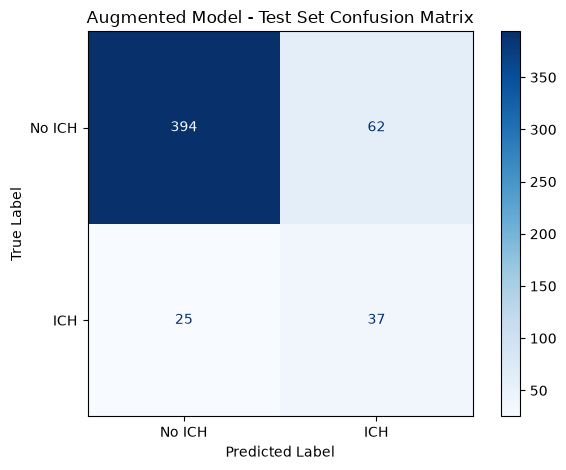

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    test_labels,
    test_predictions,
    display_labels=["No ICH", "ICH"],
    cmap="Blues",
    values_format="d",
)

plt.title("Augmented Model - Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# 6. Comparison with the Baseline

The baseline model showed limited ICH detection at the **0.5 classification threshold**, with a sensitivity of **30.65%** and an F1-score of **0.3800**, despite high specificity (**95.83%**) and AUROC (**0.8659**). This motivated the combined training strategy targeting overfitting and class imbalance.

The combined strategy improved ICH detection on the held-out test set:

| Metric      | Baseline |   Combined |
| ----------- | -------: | ---------: |
| Accuracy    |   0.8803 |     0.8320 |
| F1          |   0.3800 |     0.4596 |
| Sensitivity |   0.3065 | **0.5968** |
| Specificity |   0.9583 |     0.8640 |
| AUROC       |   0.8659 |     0.8747 |

Sensitivity increased while specificity decreased, indicating a shift toward detecting more ICH cases at the cost of additional false positives. F1 also improved, while AUROC remained similar.

The comparison uses the fixed **0.5 threshold** for both models to maintain consistency with the baseline; no threshold was tuned on the test set.


# 7. Key Takeaways

The combined training strategy shifted the classifier toward greater ICH detection, with a corresponding increase in false positives.

This experiment evaluates the three interventions only as a **combined configuration**, so their individual contributions cannot be determined. In particular, the separate effects of weighted sampling and class-weighted loss, and whether their combination results in overcorrection, remain open questions.

Future experiments could use controlled ablations to isolate the contribution of each intervention.
